AttributeError: 'CompositeGenericTransform' object has no attribute 'axes'

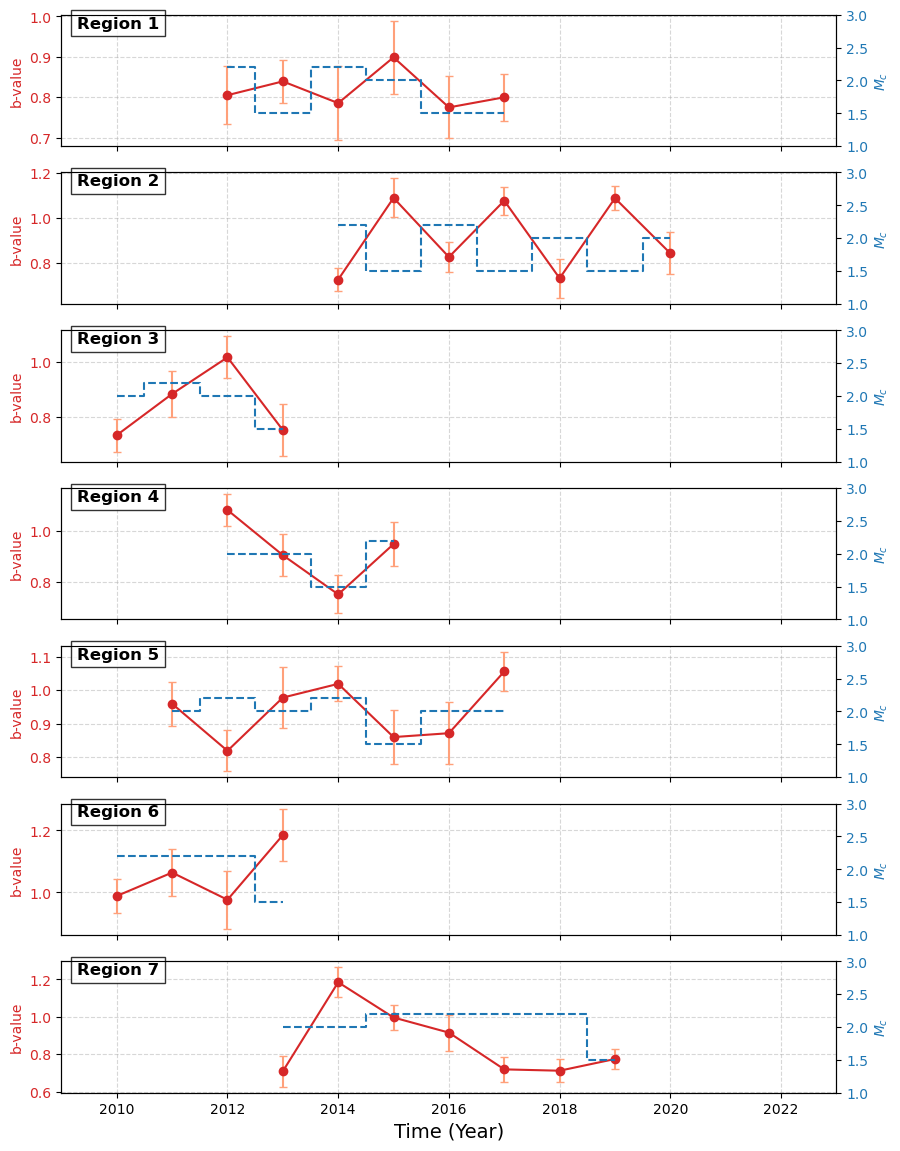

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random

# ==========================================
# 1. 模拟数据生成 (你需要替换成你的真实数据)
# ==========================================
regions_data = []
for i in range(1, 8):
    # 模拟不同的时间段：起始年份随机，持续时长随机
    start_year = np.random.randint(2010, 2015)
    duration = np.random.randint(4, 8)
    years = np.arange(start_year, start_year + duration)
    
    # 模拟 b值 (带误差)
    b_values = np.random.uniform(0.7, 1.2, size=len(years))
    b_errors = np.random.uniform(0.05, 0.1, size=len(years)) # b值的标准差
    
    # 模拟 Mc值 (通常是离散的阶梯状)
    mc_values = np.random.choice([1.5, 2.0, 2.2], size=len(years))
    
    regions_data.append({
        "name": f"Region {i}",
        "time": years,
        "b": b_values,
        "b_err": b_errors,
        "mc": mc_values
    })

# ==========================================
# 2. 绘图设置
# ==========================================
# 创建 7 行 1 列的画布，共享 X 轴
fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(10, 14), sharex=True)

# 颜色设置
color_b = '#d62728'  # 红色用于 b值
color_mc = '#1f77b4' # 蓝色用于 Mc

# ==========================================
# 3. 循环绘制每个区域
# ==========================================
for i, (ax1, data) in enumerate(zip(axes, regions_data)):
    # --- 左轴：绘制 b值 (带误差棒) ---
    ax1.errorbar(data["time"], data["b"], yerr=data["b_err"], 
                 fmt='-o', color=color_b, ecolor='lightsalmon', 
                 capsize=3, label='b-value' if i==0 else "")
    
    ax1.set_ylabel('b-value', color=color_b, fontsize=10)
    ax1.tick_params(axis='y', labelcolor=color_b)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # 在左上角标注区域名称
    ax1.text(0.02, 0.9, data["name"], transform=ax1.transAxes, 
             fontweight='bold', fontsize=12, bbox=dict(facecolor='white', alpha=0.8))

    # --- 右轴：绘制 Mc (阶梯图) ---
    ax2 = ax1.twinx()  # 创建共享X轴的第二个Y轴
    # 使用 step 函数绘制阶梯图，where='mid' 表示在时间点中间跳变
    ax2.step(data["time"], data["mc"], where='mid', 
             color=color_mc, linestyle='--', label='$M_c$' if i==0 else "")
    
    ax2.set_ylabel('$M_c$', color=color_mc, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=color_mc)
    
    # 设置右轴范围 (让阶梯图不要顶天立地，好看一点)
    ax2.set_ylim(1.0, 3.0) 

# ==========================================
# 4. 全局修饰
# ==========================================
# 设置最底部的 X 轴标签
axes[-1].set_xlabel('Time (Year)', fontsize=14)

# 统一 X 轴范围 (确保所有子图对齐，即便某些区域没数据)
plt.xlim(2009, 2023)

# 创建一个全局图例 (放在第一个子图上方，或者你可以手动调整位置)
lines_1, labels_1 = axes[0].get_legend_handles_labels()
lines_2, labels_2 = axes[0].transData.axes.right_axes[0].get_legend_handles_labels() 
# 注意：获取twinx轴的图例稍微有点麻烦，这里简单处理，实际只要说明清楚即可
fig.legend(lines_1 + [plt.Line2D([],[],color=color_mc, linestyle='--')], 
           ['b-value', '$M_c$'], 
           loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02), fontsize=12)

plt.tight_layout()
plt.show()